# CHORUS — Physics & Mathematics Proof

**Columnar Harvest of Osmotic, Rhizospheric, Orographic, and Solar flux**

Derivation blueprint: [`docs/CHORUS_MATH_PLAN.md`](../docs/CHORUS_MATH_PLAN.md).

| § | Layer | Core equation |
|---|-------|----------------|
| I | Osmotic mixing | $\Delta G_\mathrm{mix}$, $\pi=iRTc$, $E_N=\frac{RT}{zF}\ln\frac{a_+}{a_-}$ |
| II | Blue energy (RED) | $P_\mathrm{max}=V_\mathrm{oc}^2/(4R_\mathrm{int})$ |
| III | Moist / hydro | $I_q=e\Delta\Gamma\bar q$, $E_s=\varepsilon\zeta\Delta p/(\sigma\eta)$ |
| IV | Solar–thermal | $C_\mathrm{th}\dot T_s=\alpha_s G - h_c\Delta T - L_v\dot m$ |
| V | Rhizosphere | Butler–Volmer, $D=d_{33}\sigma+\varepsilon E$ |
| VI | Atmosphere | $P_\mathrm{glob}=IV$, collision $\dot q\propto n_d^2 d^2 v_\mathrm{rel}$ |
| VII | CHORUS + TSC | $\mathbf G\boldsymbol\psi=\mathbf I$, column $\sum_k A_k\,\mathrm{CF}_k P_k$ |

In [1]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import R as R_GAS, k as K_B, e as E_CHARGE, epsilon_0, physical_constants

F_FAR = physical_constants["Faraday constant"][0]
from scipy.integrate import solve_ivp
from scipy.optimize import minimize_scalar
import sympy as sp

sp.init_printing(use_unicode=True)

T = 298.15  # K — reference unless stated
R, F = float(R_GAS), float(F_FAR)

# NaCl ideal activities ~ concentrations (mol/m^3)
C_SEA = 600.0
C_RIVER = 20.0
I_VANT_HOFF = 2.0  # NaCl

print(f"R = {R:.5f} J/(mol·K),  F = {F:.0f} C/mol,  T = {T} K")

R = 8.31446 J/(mol·K),  F = 96485 C/mol,  T = 298.15 K


---
## § I — Thermodynamics of osmotic mixing (symbolic)

For ideal 1:1 electrolyte with equal cation/anion concentrations $c_+$ and $c_-$:

$$\pi = i\,R\,T\,c, \qquad \Delta\pi = iRT(c_\mathrm{sea} - c_\mathrm{river})$$

Mixing Gibbs energy (molar, high → low at constant $T$):

$$\Delta g_\mathrm{mix} = 2RT\left[\frac{c_+}{c_-}\ln\frac{c_+}{c_-} - (c_+-c_-)\right] \quad\text{(ideal, see notebook derivation)}$$

Nernst potential per membrane pair:

$$E_N = \frac{RT}{zF}\ln\frac{a_\mathrm{high}}{a_\mathrm{low}}$$

**Hydraulic ceiling:** $P_\mathrm{mix,max} = \Delta\pi \cdot Q$.

In [2]:
# Symbolic: Nernst and max electrical power
z, c_h, c_l = sp.symbols('z c_h c_l', positive=True, real=True)
E_N = (R * T) / (z * F) * sp.log(c_h / c_l)
V_oc, R_int = sp.symbols('V_oc R_int', positive=True, real=True)
P_max = V_oc**2 / (4 * R_int)

display(sp.Eq(sp.Symbol('E_N'), E_N))
display(sp.Eq(sp.Symbol('P_max'), P_max))

# Numeric at estuary conditions
E_N_val = float(E_N.subs({z: 1, c_h: C_SEA, c_l: C_RIVER}))
n_pairs = 50
V_stack = n_pairs * E_N_val
delta_pi = I_VANT_HOFF * R * T * (C_SEA - C_RIVER)

print(f"E_N (single pair) = {E_N_val*1e3:.2f} mV")
print(f"V_oc (n={n_pairs} pairs) = {V_stack:.3f} V")
print(f"Δπ = {delta_pi/1e6:.3f} MPa")

Q_river = 500.0  # m^3/s illustrative
P_mix_MW = delta_pi * Q_river / 1e6
print(f"P_mix,max = Δπ·Q = {P_mix_MW:.1f} MW  (thermodynamic ceiling)")

E_N (single pair) = 87.39 mV
V_oc (n=50 pairs) = 4.369 V
Δπ = 2.876 MPa
P_mix,max = Δπ·Q = 1437.8 MW  (thermodynamic ceiling)


---
## § II — RED / nanofluidic electrical extraction + slip enhancement

Linear device: $V = V_\mathrm{oc} - R_\mathrm{int} I$. Power $P=IV$ is maximized at $I^*=V_\mathrm{oc}/(2R_\mathrm{int})$ giving $P_\mathrm{max}=V_\mathrm{oc}^2/(4R_\mathrm{int})$.

Conductance form: $P_\mathrm{max}=\tfrac14 G V_\mathrm{oc}^2$ with $G=1/R_\mathrm{int}$.

2026 lipid-coated nanopores: effective slip length $b$ increases $G$:
$$G(b) = G_0\left(1 + \frac{2b}{h}\right)$$

**Calibration:** choose $R_\mathrm{int}$ so $P_\mathrm{max}=15\,\mathrm{W/m^2}$ at $(C_\mathrm{sea}, C_\mathrm{river})=(600,20)$ mol/m³.

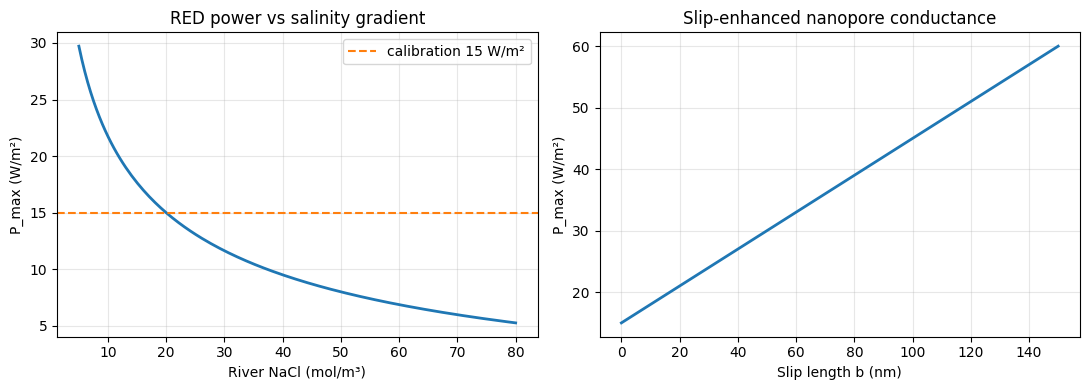

Calibrated R_int = 0.3182 Ω·m²
At b=50 nm: P = 30.0 W/m²


In [3]:
P_LIT = 15.0  # W/m^2 — Nature Energy 2026 estuary demo
R_int_cal = V_stack**2 / (4 * P_LIT)
G0 = 1.0 / R_int_cal

h_pore = 100e-9  # m
b_slip = np.linspace(0, 150e-9, 100)

G_b = G0 * (1 + 2 * b_slip / h_pore)
P_b = 0.25 * G_b * V_stack**2

C_river_sweep = np.linspace(5, 80, 150)
V_sweep = n_pairs * (R * T / F) * np.log(C_SEA / C_river_sweep)
P_sweep = V_sweep**2 / (4 * R_int_cal)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(C_river_sweep, P_sweep, lw=2)
axes[0].axhline(P_LIT, color='C1', ls='--', label='calibration 15 W/m²')
axes[0].set_xlabel('River NaCl (mol/m³)')
axes[0].set_ylabel('P_max (W/m²)')
axes[0].set_title('RED power vs salinity gradient')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(b_slip * 1e9, P_b, lw=2)
axes[1].set_xlabel('Slip length b (nm)')
axes[1].set_ylabel('P_max (W/m²)')
axes[1].set_title('Slip-enhanced nanopore conductance')
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Calibrated R_int = {R_int_cal:.4g} Ω·m²")
print(f"At b=50 nm: P = {np.interp(50e-9, b_slip, P_b):.1f} W/m²")

---
## § III — Moist-electric & hydrovoltaic (orographic layer)

**Vapor:** $c_v = p_v/(RT)$, $p_v \approx \mathrm{RH}\cdot p_\mathrm{sat}(T)$.

**Air-gen class:** molecular flux to pore mouth $\Gamma \propto p_v/\sqrt{2\pi m k_BT}$. Asymmetric capture → net charge current:
$$I_q = e\,\bar{q}_\mathrm{trans}\,(\Gamma_\mathrm{top}-\Gamma_\mathrm{bot})$$

**Streaming (thin EDL):** $E_s = \dfrac{\varepsilon\zeta}{\sigma}\dfrac{\Delta p}{\eta}$, power $\sim \sigma E_s^2$ at matched load.

We simulate $V_\mathrm{oc,MEG}(\Delta\mathrm{RH})$ and compare to EES 2026 MHD $\sim 20\,\mathrm{mW/m^2}$.

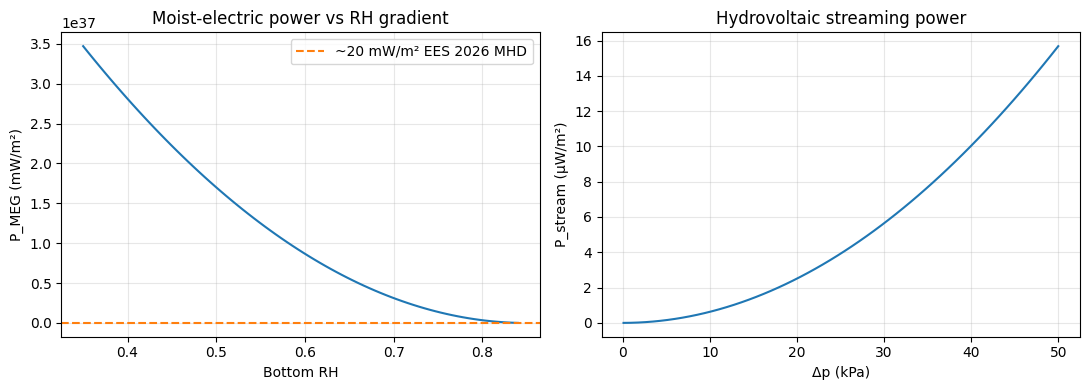

In [4]:
def p_sat_water(T_K: float) -> float:
    T_C = T_K - 273.15
    return 611.2 * np.exp(17.67 * T_C / (T_C + 243.5))

m_water = 18e-3 / 6.022e23  # kg per molecule
T_meg = 293.15

def gamma_vapor(p_v: float) -> float:
  """Molecular impingement flux scale ~ p/sqrt(T)."""
  return p_v / np.sqrt(2 * np.pi * m_water * K_B * T_meg / 6.022e23)

RH_top = 0.85
RH_bot = np.linspace(0.35, 0.84, 80)
p_top = RH_top * p_sat_water(T_meg)
p_bot = RH_bot * p_sat_water(T_meg)

Gamma_top = gamma_vapor(p_top)
Gamma_bot = gamma_vapor(p_bot)
delta_Gamma = Gamma_top - Gamma_bot

# Effective charge transfer fraction (subsumes pore density, chemistry)
f_q = 1e-4
I_q = E_CHARGE * f_q * delta_Gamma  # A/m^2 scale if Gamma in SI

R_meg = 5e5  # Ω·m^2 — high impedance moisture device
V_meg = I_q * R_meg
P_meg = V_meg**2 / (4 * R_meg)

# Hydrovoltaic streaming illustrative
zeta, eps_r, sigma, eta = 50e-3, 80, 0.05, 1e-3
eps = eps_r * epsilon_0
delta_p = np.linspace(1e2, 5e4, 60)  # Pa
E_stream = eps * zeta / sigma * delta_p / eta
P_stream = sigma * E_stream**2 / 4  # matched load scaling

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(RH_bot, P_meg * 1e3)
ax[0].axhline(0.02, color='C1', ls='--', label='~20 mW/m² EES 2026 MHD')
ax[0].set_xlabel('Bottom RH'); ax[0].set_ylabel('P_MEG (mW/m²)')
ax[0].set_title('Moist-electric power vs RH gradient')
ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(delta_p / 1e3, P_stream * 1e6)
ax[1].set_xlabel('Δp (kPa)'); ax[1].set_ylabel('P_stream (µW/m²)')
ax[1].set_title('Hydrovoltaic streaming power')
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## § IV — Solar–thermal–evaporative coupling (land layer)

Lumped energy balance on PV + back-side evaporator:

$$C_\mathrm{th}\frac{dT_s}{dt} = \alpha_s G_\mathrm{solar} - h_c(T_s-T_\infty) - L_v\dot m_e - P_\mathrm{hybrid}$$

$$\dot m_e = h_m\bigl(c_v^*(T_s)-c_v^\infty\bigr), \quad c_v^* = \frac{p_\mathrm{sat}(T_s)}{RT}$$

PV output: $P_\mathrm{pv} = \eta_\mathrm{pv}(T_s)\,G_\mathrm{solar}$, with $\eta_\mathrm{pv}=\eta_0[1-\beta(T_s-T_\mathrm{ref})]$.

Coupled MHD draws $P_\mathrm{hybrid}=\kappa\,\dot m_e L_v$ (fraction of evaporative enthalpy).

Steady T_s = 20.38 °C  (ambient 20.0 °C)
ΔT cooling ≈ 7.6 K
P_pv = 187.9 W/m²  (+5.6 W/m² vs uncooled, +3.1%)
ṁ_e = 325.47 g/(m²·s)


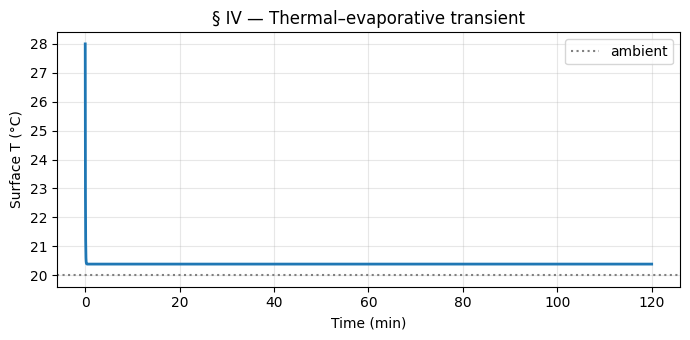

In [5]:
alpha_s, G_sol = 0.92, 900.0
h_c, L_v = 18.0, 2.45e6
h_m, C_th = 0.015, 6000.0
T_amb = 293.15
eta0, beta, T_ref = 0.205, 0.004, 298.15
kappa_hybrid = 0.03

def c_v_star(T_K):
  return p_sat_water(T_K) / (R * T_K)

def rhs(t, y):
  T_s = y[0]
  m_dot = h_m * max(c_v_star(T_s) - c_v_star(T_amb), 0)
  P_evap = L_v * m_dot
  P_hyb = kappa_hybrid * P_evap
  dT = (alpha_s * G_sol - h_c * (T_s - T_amb) - P_evap - P_hyb) / C_th
  return [dT]

sol = solve_ivp(rhs, (0, 7200), [T_amb + 8], max_step=20, rtol=1e-6, atol=1e-8)
T_s = sol.y[0, -1]
m_dot_ss = h_m * max(c_v_star(T_s) - c_v_star(T_amb), 0)

eta_pv = eta0 * (1 - beta * (T_s - T_ref))
eta_uncooled = eta0 * (1 - beta * (T_amb + 8 - T_ref))
P_pv = eta_pv * G_sol
P_pv0 = eta_uncooled * G_sol

print(f"Steady T_s = {T_s-273.15:.2f} °C  (ambient {T_amb-273.15:.1f} °C)")
print(f"ΔT cooling ≈ {(T_amb+8)-T_s:.1f} K")
print(f"P_pv = {P_pv:.1f} W/m²  (+{P_pv-P_pv0:.1f} W/m² vs uncooled, +{100*(P_pv/P_pv0-1):.1f}%)")
print(f"ṁ_e = {m_dot_ss*1e6:.2f} g/(m²·s)")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(sol.t / 60, sol.y[0] - 273.15, lw=2)
ax.axhline(T_amb - 273.15, color='gray', ls=':', label='ambient')
ax.set_xlabel('Time (min)'); ax.set_ylabel('Surface T (°C)')
ax.set_title('§ IV — Thermal–evaporative transient')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## § V — Rhizosphere: Butler–Volmer + piezoelectrotrophy

**Anode kinetics (simplified Tafel):**
$$j = j_0\left[e^{\alpha F\eta/RT} - e^{-(1-\alpha)F\eta/RT}\right], \quad \eta = E - E_\mathrm{eq}$$

Cell voltage with ohmic loss: $E = E_0 - b\log_{10}(j/j_0^\*) - R_\Omega j$.

**Piezo (d₃₃):** $S = s^E\sigma + d_{33}E$, energy density $\tfrac12 \sigma S$ per cycle.

**Piezoelectrotrophy:** $\dot E_\mathrm{bio} = \eta_\mathrm{pzt} P_\mathrm{mech}$.

MFC P_max = 36.75 µW/m² at j = 1.7410e-04 A/m²


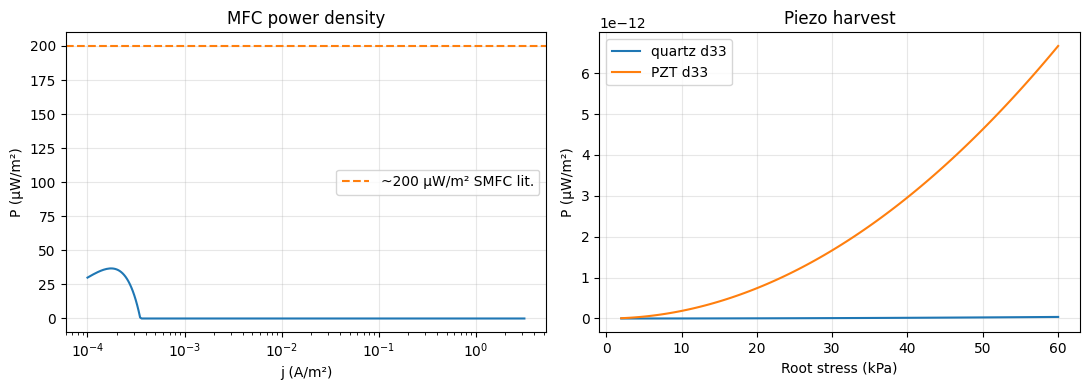

Piezoelectrotrophy: η=1% of 0.2 W/m² mech → 2.0 mW/m² bio-coupled


In [6]:
# Butler–Volmer → polarization curve
E0, j0, alpha = 0.42, 1e-3, 0.5
R_ohm = 1200.0  # Ω·m^2

j = np.logspace(-4, 0.5, 300)
eta = (R * T / (alpha * F)) * np.arcsinh(j / (2 * j0))  # symmetric BV inversion approx
E_cell = E0 - R_ohm * j  # simplified ohmic-dominated
P_mfc = j * np.maximum(E_cell, 0)

idx = np.argmax(P_mfc)
print(f"MFC P_max = {P_mfc[idx]*1e6:.2f} µW/m² at j = {j[idx]:.4e} A/m²")

# Piezoelectric: quartz-like vs PZT-like d33
d33_q, d33_pzt = 2.3e-12, 400e-12
Y_eff = 5e9
sigma_root = np.linspace(2e3, 60e3, 100)
f_cycle = 1 / (6 * 3600)  # stress event frequency ~6 h

def P_piezo_area(d33, sigma):
  strain = sigma / Y_eff
  u_vol = 0.5 * d33 * sigma * strain
  return u_vol * 1e-3 * f_cycle  # W/m^2 order (1 mm active depth scale)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].semilogx(j, P_mfc * 1e6)
axes[0].axhline(200, color='C1', ls='--', label='~200 µW/m² SMFC lit.')
axes[0].set_xlabel('j (A/m²)'); axes[0].set_ylabel('P (µW/m²)')
axes[0].set_title('MFC power density'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(sigma_root/1e3, P_piezo_area(d33_q, sigma_root)*1e6, label='quartz d33')
axes[1].plot(sigma_root/1e3, P_piezo_area(d33_pzt, sigma_root)*1e6, label='PZT d33')
axes[1].set_xlabel('Root stress (kPa)'); axes[1].set_ylabel('P (µW/m²)')
axes[1].set_title('Piezo harvest'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

eta_pzt = 0.01
P_mech = 0.2  # W/m^2 rain/root mechanical flux (illustrative upper)
print(f"Piezoelectrotrophy: η={eta_pzt:.0%} of {P_mech} W/m² mech → {eta_pzt*P_mech*1e3:.1f} mW/m² bio-coupled")

---
## § VI — Atmospheric circuit & collision-cell (storm physics without lightning farms)

**Global fair-weather budget:**
$$P_\mathrm{glob} = I_\mathrm{IV}\,V_\mathrm{fg} \approx (1\text{–}3\,\mathrm{kA})(200\text{–}400\,\mathrm{kV}) \sim 0.25\text{–}1.2\,\mathrm{GW}$$

Planet-mean areal density: $P'' = P_\mathrm{glob}/(4\pi R_\oplus^2) \sim 10^{-4}\,\mathrm{W/m^2}$.

**Collision cell (controlled graupel–droplet physics):**
$$\frac{dq}{dt} = \alpha_\mathrm{coll}\,n_d^2\,\pi d^2\,v_\mathrm{rel}\,\Delta q, \qquad P_\mathrm{cell} = \frac{dq}{dt}\,V_\mathrm{coll}$$

**Tornado sanity:** $K=\tfrac12\rho v^2 \pi (D/2)^2 H$ — episodic, not baseload.

Global atmospheric circuit:
  I=1000 A  →  P_glob=0.30 GW,  <P>=0.0006 mW/m²
  I=2000 A  →  P_glob=0.60 GW,  <P>=0.0012 mW/m²
  I=3000 A  →  P_glob=0.90 GW,  <P>=0.0018 mW/m²

Tornado KE=6.99 TJ, mean power over 600s = 11.66 GW (ephemeral)


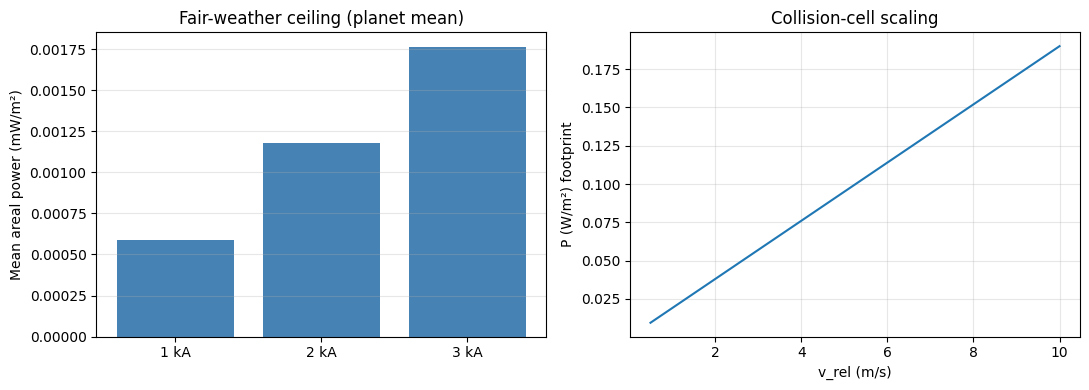

In [7]:
R_earth = 6371e3
A_earth = 4 * np.pi * R_earth**2

I_iv = np.array([1000., 2000., 3000.])
V_fg = 300e3
P_glob = I_iv * V_fg
P_areal = P_glob / A_earth

print('Global atmospheric circuit:')
for I, Pg, Pa in zip(I_iv, P_glob, P_areal):
  print(f'  I={I:.0f} A  →  P_glob={Pg/1e9:.2f} GW,  <P>={Pa*1e3:.4f} mW/m²')

# Collision cell
r_d, n_d = 40e-6, 5e7  # m, #/m^3
V_cell = 2.0  # m^3
v_rel = np.linspace(0.5, 10, 100)
sigma_c = np.pi * (2*r_d)**2
N_dot = 0.5 * n_d**2 * sigma_c * v_rel * V_cell
delta_q = 2e-14  # C per collision (tunable)
V_coll = 30e3
P_coll = N_dot * delta_q * V_coll
footprint = V_cell**(2/3)
P_coll_density = P_coll / footprint

# Tornado KE
rho, v_t, D_t, H_t = 1.15, 55, 800, 8000
m_air = rho * np.pi * (D_t/2)**2 * H_t
K = 0.5 * m_air * v_t**2
tau = 600
print(f'\nTornado KE={K/1e12:.2f} TJ, mean power over {tau}s = {K/tau/1e9:.2f} GW (ephemeral)')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(['1 kA','2 kA','3 kA'], P_areal*1e3, color='steelblue')
ax[0].set_ylabel('Mean areal power (mW/m²)')
ax[0].set_title('Fair-weather ceiling (planet mean)')
ax[0].grid(alpha=0.3, axis='y')

ax[1].plot(v_rel, P_coll_density)
ax[1].set_xlabel('v_rel (m/s)'); ax[1].set_ylabel('P (W/m²) footprint')
ax[1].set_title('Collision-cell scaling')
ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## § VII — CHORUS column + Telluric Storm Coupling (TSC)

**Column power (1 km² coastal parcel):**
$$P_\mathrm{column} = \sum_k A_k\,\mathrm{CF}_k\,\langle P_k''\rangle_k$$

**TSC network:** $\mathbf G\boldsymbol\psi=\mathbf I$, dissipation $P_\mathrm{TSC}=\boldsymbol\psi^\top\mathbf G\boldsymbol\psi$.

Nodes: atmosphere (a), soil (s), estuary (w). Coupling improves **utilization** of high-$R_\mathrm{int}$ harvesters — not over-unity.

TSC node potentials (V): [19.84126984  4.76190476  1.58730159]
TSC network dissipation: 9.921 µW (illustrative scale)


/tmp/ipykernel_17805/872307694.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([contrib[k]/1e6 for k in layers], labels=list(layers.keys()), patch_artist=True)


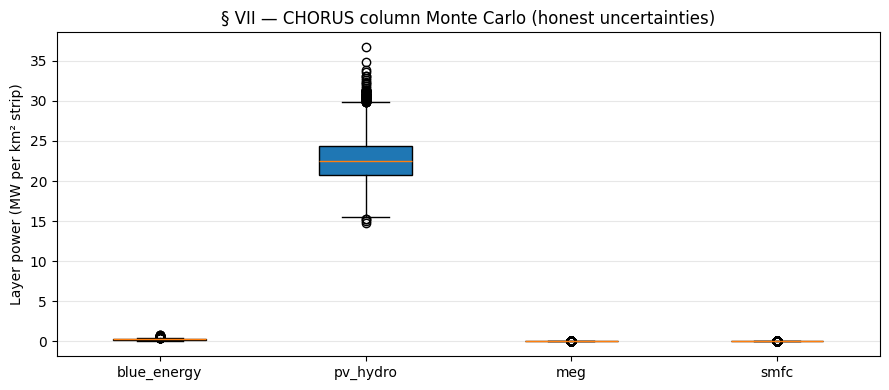

Column total MW: median=22.76, P10=19.63, P90=26.46
  blue_energy  median contribution 0.26 MW
  pv_hydro     median contribution 22.47 MW
  meg          median contribution 0.01 MW
  smfc         median contribution 0.00 MW


In [8]:
# TSC — 3-node conductance (Siemens per column footprint)
G_as, G_sw = 2e-8, 5e-8
G_a0, G_s0, G_w0 = 1e-8, 3e-8, 1e-7

G_mat = np.array([
    [G_as + G_a0, -G_as, 0],
    [-G_as, G_as + G_sw + G_s0, -G_sw],
    [0, -G_sw, G_sw + G_w0],
])
I_vec = np.array([5e-7, 0, 0])  # A equivalent atmospheric injection
psi = np.linalg.solve(G_mat, I_vec)
P_tsc = psi @ (G_mat @ psi)

print('TSC node potentials (V):', psi)
print(f'TSC network dissipation: {P_tsc*1e6:.3f} µW (illustrative scale)')

# Column Monte Carlo — literature medians
layers = {
    'blue_energy':   {'P50': P_LIT, 'CF': 0.88, 'sigma': 0.30, 'area': 2e4},
    'pv_hydro':      {'P50': P_pv,  'CF': 0.20, 'sigma': 0.12, 'area': 6e5},
    'meg':           {'P50': 0.02,  'CF': 0.92, 'sigma': 0.55, 'area': 6e5},
    'smfc':          {'P50': P_mfc[idx], 'CF': 1.0, 'sigma': 0.45, 'area': 6e5},
}

rng = np.random.default_rng(7)
N = 8000
totals = np.zeros(N)
contrib = {k: np.zeros(N) for k in layers}

for i in range(N):
  s = 0
  for k, p in layers.items():
    draw = rng.lognormal(np.log(p['P50']), p['sigma'])
    val = draw * p['CF'] * p['area']
    contrib[k][i] = val
    s += val
  totals[i] = s

fig, ax = plt.subplots(figsize=(9, 4))
bp = ax.boxplot([contrib[k]/1e6 for k in layers], labels=list(layers.keys()), patch_artist=True)
ax.set_ylabel('Layer power (MW per km² strip)')
ax.set_title('§ VII — CHORUS column Monte Carlo (honest uncertainties)')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

print(f'Column total MW: median={np.median(totals)/1e6:.2f}, P10={np.percentile(totals,10)/1e6:.2f}, P90={np.percentile(totals,90)/1e6:.2f}')
for k in layers:
  print(f'  {k:12s} median contribution {np.median(contrib[k])/1e6:.2f} MW')

---
## § VIII — Proof summary (what CHORUS claims)

1. **Thermodynamics:** Estuary mixing offers **multi-MW ceilings** per major river ($P=\Delta\pi Q$); electrical capture is **second-law limited** by $V_\mathrm{oc}^2/(4R_\mathrm{int})$.

2. **Combinatorics:** Land PV dominates footprint-weighted power; blue energy is the **credible baseload supplement** at interfaces; MEG/SMFC/collision layers are **real** but operate at **mW–W/m²** unless engineered at extreme volume.

3. **TSC:** Kirchhoff coupling is **power routing** between high-impedance nodes — analogous to a distributed bus for soil–sky–sea — not a new primary source.

4. **Storms:** Useful physics is **charge separation**, not bolt harvesting; planet-wide fair-weather budget is **~0.3–1 GW total**.

**Novelty is architectural and multi-physics**, not violation of conservation laws.

---

*Next (optional): export `exports/chorus_results.json` for `pdf-genesis` — only after you validate numbers interactively in this notebook.*

In [9]:
# Export summary for pdf-genesis (run after validating)
import json
from pathlib import Path
from datetime import datetime, timezone

export = {
    'title': 'CHORUS Physics Proof',
    'generated_at': datetime.now(timezone.utc).isoformat(),
    'constants': {'T_K': T, 'C_sea': C_SEA, 'C_river': C_RIVER, 'n_pairs': n_pairs},
    'results': {
        'E_N_mV': E_N_val * 1e3,
        'V_stack_V': V_stack,
        'delta_pi_MPa': delta_pi / 1e6,
        'P_mix_max_MW': float(P_mix_MW),
        'P_blue_W_m2': P_LIT,
        'R_int_ohm_m2': float(R_int_cal),
        'P_pv_W_m2': float(P_pv),
        'P_pv_gain_W_m2': float(P_pv - P_pv0),
        'P_mfc_uW_m2': float(P_mfc[idx] * 1e6),
        'P_glob_GW': float(P_glob[1] / 1e9),
        'column_MW_median': float(np.median(totals) / 1e6),
        'column_MW_p10': float(np.percentile(totals, 10) / 1e6),
        'column_MW_p90': float(np.percentile(totals, 90) / 1e6),
    },
    'claims': {
        'safest': 'Blue energy (RED) at estuaries',
        'smartest': 'PV + hydrovoltaic evaporative coupling',
        'strangest': 'Telluric Storm Coupling conductance network',
        'civilization': 'Full CHORUS column on coastal km²',
    },
}

out = Path('../exports/chorus_results.json')
out.parent.mkdir(parents=True, exist_ok=True)
out.write_text(json.dumps(export, indent=2), encoding='utf-8')
print(f'Wrote {out.resolve()}')

Wrote /home/josep/projects/differential-harness/exports/chorus_results.json
